In [180]:
import numpy as np
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt

def convert2dataframe(recall_rate_results,order):
    data = []
    
    for method_name in order:
        recall_rate_matrix = recall_rate_results[method_name]
        for run_idx , rr in enumerate(recall_rate_matrix):
            for  k in range(1,11):
                data.append([method_name,run_idx, k, rr[k-1]])

    return pd.DataFrame(data, columns=['method','run', 'k', 'Recall Rate@k'])

def convert2dataframe_diff(recall_rate_results):
    data = []
    
    for method_name, recall_rate_matrix in recall_rate_results.items():
        recall_rate_matrix = np.round(recall_rate_matrix,2)
        row = [method_name]
        row.extend(recall_rate_matrix)
        data.append(row)

    return pd.DataFrame(data, columns=['Method'] + list(range(1,21)))

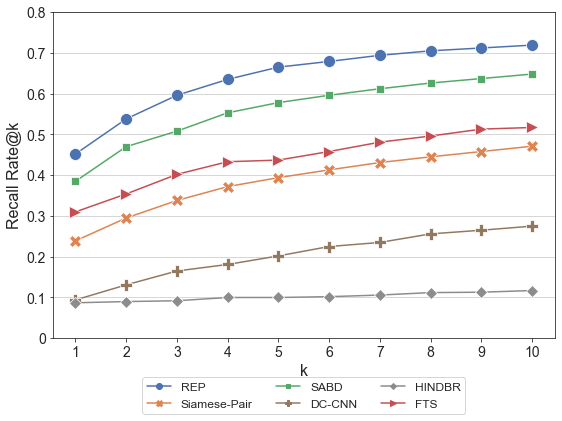

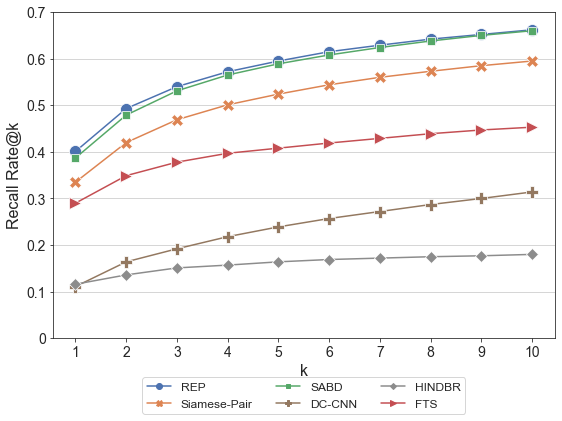

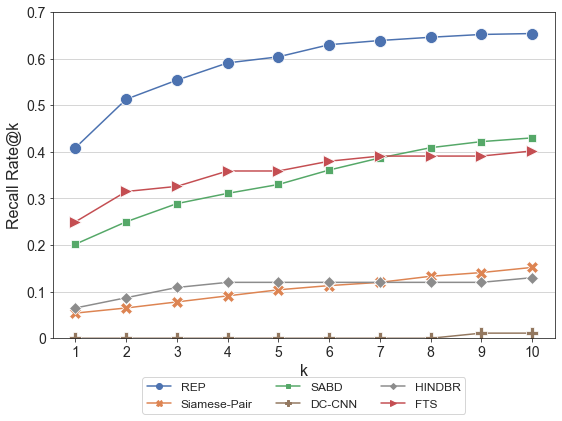

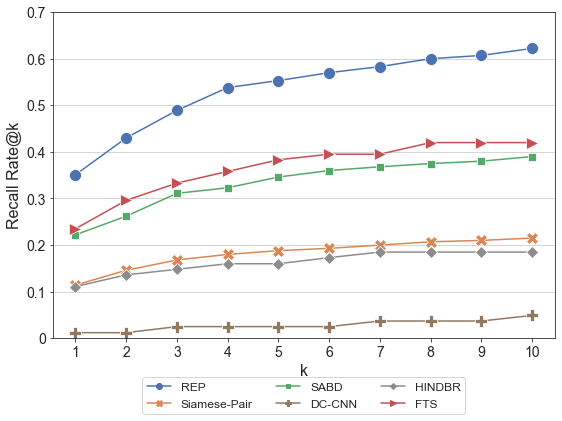

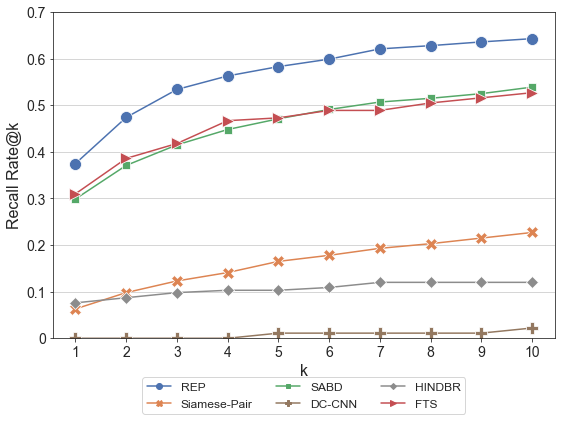

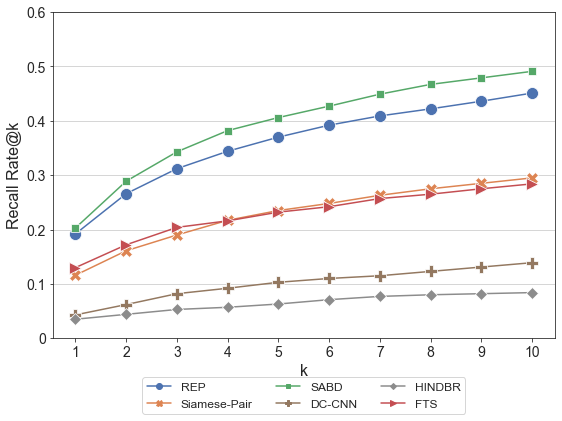

In [218]:
# Comparison (6 charts)

from tkinter import Y, font


raw_num = {
    'Eclipse': """0.452	0.239	0.385	0.094	0.087	0.310
0.538	0.295	0.470	0.131	0.090	0.354
0.596	0.338	0.508	0.165	0.092	0.402
0.635	0.372	0.553	0.181	0.100	0.433
0.665	0.394	0.578	0.202	0.100	0.437
0.679	0.413	0.596	0.225	0.102	0.458
0.694	0.431	0.612	0.235	0.106	0.481
0.705	0.445	0.626	0.256	0.112	0.496
0.712	0.458	0.637	0.265	0.113	0.513
0.719	0.471	0.648	0.275	0.117	0.517""",
    'Mozilla': """0.401	0.335	0.387	0.111	0.116	0.290
0.493	0.420	0.479	0.164	0.136	0.349
0.540	0.469	0.531	0.192	0.151	0.378
0.572	0.501	0.565	0.218	0.157	0.397
0.595	0.524	0.589	0.239	0.164	0.408
0.615	0.544	0.608	0.257	0.169	0.419
0.629	0.560	0.624	0.272	0.172	0.429
0.642	0.573	0.638	0.287	0.175	0.439
0.652	0.585	0.650	0.300	0.177	0.447
0.662	0.595	0.660	0.314	0.180	0.453""",
    "Hadoop": """0.409	0.054	0.202	0.000	0.065	0.250
0.513	0.065	0.250	0.000	0.087	0.315
0.554	0.078	0.289	0.000	0.109	0.326
0.591	0.091	0.311	0.000	0.120	0.359
0.604	0.104	0.330	0.000	0.120	0.359
0.630	0.113	0.361	0.000	0.120	0.380
0.639	0.120	0.387	0.000	0.120	0.391
0.646	0.133	0.409	0.000	0.120	0.391
0.652	0.141	0.422	0.011	0.120	0.391
0.654	0.152	0.430	0.011	0.130	0.402""",
    "Spark": """0.351	0.114	0.222	0.012	0.111	0.235
0.430	0.146	0.262	0.012	0.136	0.296
0.489	0.168	0.311	0.025	0.148	0.333
0.538	0.180	0.323	0.025	0.160	0.358
0.553	0.188	0.346	0.025	0.160	0.383
0.570	0.193	0.360	0.025	0.173	0.395
0.583	0.200	0.368	0.037	0.185	0.395
0.600	0.207	0.375	0.037	0.185	0.420
0.607	0.210	0.380	0.037	0.185	0.420
0.622	0.215	0.390	0.049	0.185	0.420""",
    "Kibana": """0.375	0.063	0.299	0.000	0.076	0.310
0.474	0.098	0.371	0.000	0.087	0.386
0.534	0.123	0.415	0.000	0.098	0.418
0.563	0.141	0.448	0.000	0.103	0.467
0.583	0.165	0.471	0.011	0.103	0.473
0.599	0.178	0.491	0.011	0.109	0.489
0.621	0.193	0.507	0.011	0.120	0.489
0.628	0.203	0.515	0.011	0.120	0.505
0.636	0.215	0.525	0.011	0.120	0.516
0.643	0.227	0.539	0.022	0.120	0.527""",
    "VSCode": """0.192	0.116	0.203	0.043	0.035	0.130
0.266	0.161	0.289	0.062	0.044	0.172
0.312	0.190	0.343	0.082	0.053	0.204
0.344	0.217	0.382	0.092	0.057	0.216
0.370	0.235	0.406	0.103	0.063	0.232
0.392	0.248	0.427	0.110	0.071	0.242
0.409	0.263	0.449	0.115	0.077	0.257
0.422	0.275	0.467	0.123	0.080	0.265
0.436	0.285	0.479	0.131	0.082	0.275
0.451	0.295	0.491	0.139	0.084	0.284"""
}

for project_name in raw_num:
    numbers = raw_num[project_name].replace('\n', '\t').split('\t')
    numbers = [float(x) for x in numbers]

    y_min = max(0, min(numbers)-0.05*(min(numbers)))
    y_max = min(1, max(numbers)+0.05*(max(numbers)))
    data = {}
    tech_order = {0: "REP", 1: "Siamese-Pair", 2: "SABD", 3: "DC-CNN", 4: "HINDBR", 5: "FTS"}

    for i in range(len(numbers)):
        tid = i%6
        data[tech_order[tid]] = data.get(tech_order[tid], [])
        data[tech_order[tid]].append(numbers[i])

    # data

    recall_rate_res = {
    'REP': np.asarray([
        data['REP']
        ]),
    "Siamese-Pair":  np.asarray([
        data['Siamese-Pair']
        ]),
    "SABD":  np.asarray([
        data['SABD']
        ]),
    "DC-CNN":  np.asarray([
        data['DC-CNN']
        ]),
    "HINDBR":  np.asarray([
        data['HINDBR']
        ]),
    "FTS":  np.asarray([
        data['FTS']
        ])
    }

    sn.set_style("ticks")
    flatui = ["#4C72B0", "#DD8452", "#55A868", "#937860", "#8C8C8C", "#C44E52"]
    sn.set_palette(sn.color_palette(flatui))

    plt.figure(figsize=(9, 6))

    order = ["REP", "Siamese-Pair", "SABD", "DC-CNN", "HINDBR", "FTS"]

    # order.reverse()

    k = list(range(1,11))
    ax = sn.lineplot(x="k",y='Recall Rate@k',ci='sd', hue='method', style='method', markers=True, markersize=12, dashes=False, data=convert2dataframe(recall_rate_res,order))
    # ax.set(title=project_name)
    # ax.title.set_fontsize(14)

    import matplotlib.ticker as ticker
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles[0:], labels=labels[0:], loc='lower center')
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3, fontsize=12)

    # leg = ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3, fontsize=12)
    leg_lines = ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3, fontsize=12).get_lines()

    # set FTR marker
    ax.lines[5].set_marker('>')
    leg_lines[5].set_marker('>')

    y_min = 0
    ax.set(ylim=(y_min, y_max))
    #  set the ticks first
    
    ax.set_xlabel("k",fontsize=16)
    ax.set_ylabel("Recall Rate@k",fontsize=16)
    tick = y_min
    tick_label=[int(0)]
    while tick <= y_max:
        tick_label.append(tick + 0.1)
        tick += 0.1

    ax.tick_params(labelsize=14)
    ax.set_yticks(tick_label)

    tick_label = [str(round(x,1)) for x in tick_label]
    tick_label[0] = int(0)
    ax.set_yticklabels(tick_label)

    ax.grid()
    ax.grid(axis='x')

    fig = ax.get_figure()
    fig.savefig(f"30Aug_plots/Comparison-{project_name}.pdf", format='pdf', bbox_inches='tight', pad_inches=0)

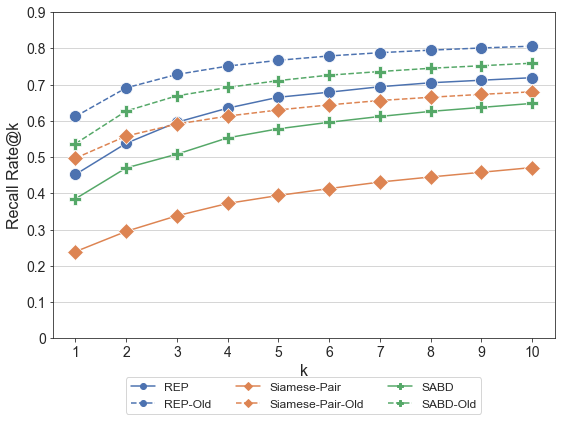

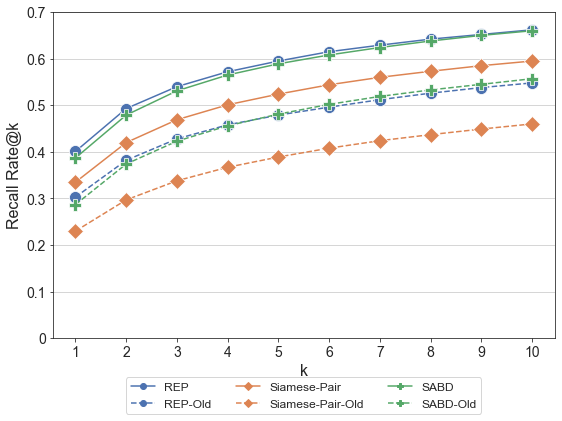

In [219]:
# R1-Age-Bugzilla (2 charts)

raw_num = {
    'Eclipse': 
        {'REP': [0.452, 0.538, 0.596, 0.635, 0.665, 0.679, 0.694, 0.705, 0.712, 0.719],
        'Siamese-Pair': [0.239, 0.295, 0.338, 0.372, 0.394, 0.413, 0.431, 0.445, 0.458, 0.471],
        'SABD': [0.385,0.470,0.508,0.553,0.578,0.596,0.612,0.626,0.637,0.648],
        'REP-Old': [0.612,0.691,0.728,0.751,0.767,0.779,0.788,0.795,0.801,0.806],
        'Siamese-Pair-Old': [0.497,0.558,0.591,0.613,0.630,0.644,0.656,0.665,0.673,0.680],
        'SABD-Old': [0.537,0.627,0.669,0.692,0.711,0.726,0.736,0.745,0.752,0.759],
    } ,
    "Mozilla": 
        {'REP': [0.401,0.493,0.540,0.572,0.595,0.615,0.629,0.642,0.652,0.662],
        'Siamese-Pair': [0.335,0.420,0.469,0.501,0.524,0.544,0.560,0.573,0.585,0.595],
        'SABD': [0.387,0.479,0.531,0.565,0.589,0.608,0.624,0.638,0.650,0.660],
        'REP-Old': [0.303,0.382,0.428,0.458,0.479,0.496,0.512,0.526,0.538,0.548],
        'Siamese-Pair-Old': [0.230,0.297,0.338,0.367,0.389,0.408,0.424,0.437,0.449,0.460],
        'SABD-Old': [0.287,0.374,0.423,0.456,0.481,0.502,0.519,0.533,0.545,0.557],
    }
}

for project_name in raw_num:
    data = raw_num[project_name]
    y_min = 1
    y_max = 0

    for key in data:
        y_min = min(y_min, min(data[key]))
        y_max = max(y_max, max(data[key]))

    y_min = max(0, y_min-0.05*y_min)
    y_max = min(1, y_max+0.05*y_max)
    tech_order = {0: "REP", 1: "REP-Old", 2: "Siamese-Pair", 3: "Siamese-Pair-Old", 4: "SABD", 5: "SABD-Old"}

    recall_rate_res = {
    'REP': np.asarray([
        data['REP']
        ]),
    "Siamese-Pair":  np.asarray([
        data['Siamese-Pair']
        ]),
    "SABD":  np.asarray([
        data['SABD']
        ]),
    "REP-Old":  np.asarray([
        data['REP-Old']
        ]),
    "Siamese-Pair-Old":  np.asarray([
        data['Siamese-Pair-Old']
        ]),
    "SABD-Old":  np.asarray([
        data['SABD-Old']
        ])
    }

    sn.set_style("ticks")
    flatui = ["#4C72B0", "#4C72B0", "#DD8452", "#DD8452", "#55A868", "#55A868"]
    # "#937860", "#8C8C8C", "#C44E52"]
    sn.set_palette(sn.color_palette(flatui))

    plt.figure(figsize=(9, 6))

    # order = ["REP", "Siamese-Pair", "SABD", "DC-CNN", "HINDBR", "FTS"]
    order = tech_order.values()

    # order.reverse()

    k = list(range(1,11))
    ax = sn.lineplot(x="k",y='Recall Rate@k',ci='sd', hue='method', style='method', markers=True, markersize=12, dashes=False, data=convert2dataframe(recall_rate_res,order))
    # ax.set(title=f"{project_name} recent vs {project_name} old")
    # ax.title.set_fontsize(14)

    import matplotlib.ticker as ticker
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())

    ax.set(ylim=(y_min, y_max))
    leg = ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3, fontsize=12)
    leg_lines = leg.get_lines()

    for i in range(6):
        if i%2 == 1:
            ax.lines[i].set_linestyle("--")
            leg_lines[i].set_linestyle("--")

    for i in range(6):
        if i < 2:
            ax.lines[i].set_marker('o')
            leg_lines[i].set_marker("o")
            continue
        if i < 4:
            ax.lines[i].set_marker('D')
            leg_lines[i].set_marker("D")
        else:
            ax.lines[i].set_marker('P')
            leg_lines[i].set_marker("P")

    y_min = 0
    ax.set(ylim=(y_min, y_max))
    #  set the ticks first
    
    ax.set_xlabel("k",fontsize=16)
    ax.set_ylabel("Recall Rate@k",fontsize=16)
    tick = y_min
    tick_label=[int(0)]
    while tick <= y_max:
        tick_label.append(tick + 0.1)
        tick += 0.1

    ax.tick_params(labelsize=14)
    ax.set_yticks(tick_label)

    tick_label = [str(round(x,1)) for x in tick_label]
    tick_label[0] = int(0)
    ax.set_yticklabels(tick_label)

    ax.grid()
    ax.grid(axis='x')

    fig = ax.get_figure()
    fig.savefig(f"30Aug_plots/R1-Age-Bugzilla-{project_name}.pdf", format='pdf', bbox_inches='tight', pad_inches=0)

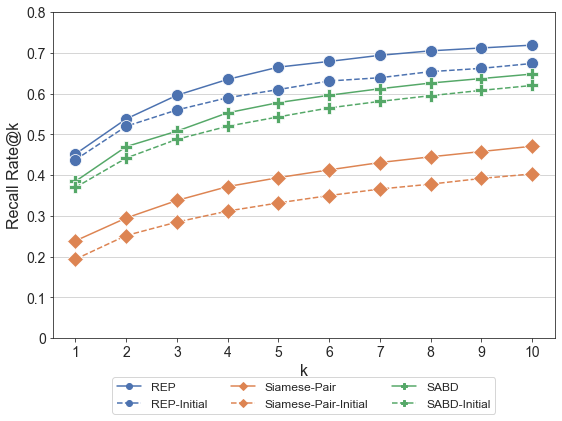

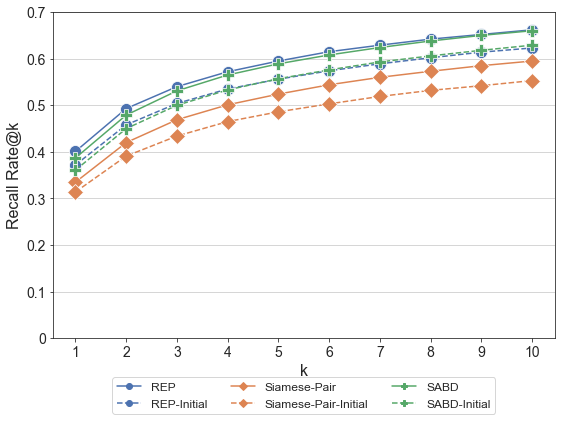

In [220]:
# R1-State-Bugzilla (2 charts)

raw_num = {
    'Eclipse': 
        {'REP': [0.452,0.538,0.596,0.635,0.665,0.679,0.694,0.705,0.712,0.719],
        'Siamese-Pair': [0.239,0.295,0.338,0.372,0.394,0.413,0.431,0.445,0.458,0.471],
        'SABD': [0.385,0.470,0.508,0.553,0.578,0.596,0.612,0.626,0.637,0.648],
        'REP-Initial': [0.438,0.520,0.560,0.590,0.610,0.631,0.639,0.654,0.662,0.674],
        'Siamese-Pair-Initial': [0.194,0.252,0.285,0.312,0.332,0.350,0.366,0.378,0.392,0.403],
        'SABD-Initial': [0.370,0.442,0.488,0.520,0.543,0.565,0.581,0.595,0.608,0.620],
    } ,
    "Mozilla": 
        {'REP': [0.401,0.493,0.540,0.572,0.595,0.615,0.629,0.642,0.652,0.662],
        'Siamese-Pair': [0.335,0.420,0.469,0.501,0.524,0.544,0.560,0.573,0.585,0.595],
        'SABD': [0.387,0.479,0.531,0.565,0.589,0.608,0.624,0.638,0.650,0.660],
        'REP-Initial': [0.372,0.458,0.504,0.535,0.556,0.574,0.589,0.602,0.614,0.623],
        'Siamese-Pair-Initial': [0.314,0.391,0.434,0.465,0.486,0.503,0.519,0.532,0.542,0.553],
        'SABD-Initial': [0.361,0.450,0.500,0.533,0.557,0.576,0.593,0.606,0.618,0.629],
    }
}

for project_name in raw_num:
    data = raw_num[project_name]
    y_min = 1
    y_max = 0

    for key in data:
        y_min = min(y_min, min(data[key]))
        y_max = max(y_max, max(data[key]))

    y_min = max(0, y_min-0.05*y_min)
    y_max = min(1, y_max+0.05*y_max)
    tech_order = {0: "REP", 1: "REP-Initial", 2: "Siamese-Pair", 3: "Siamese-Pair-Initial", 4: "SABD", 5: "SABD-Initial"}

    recall_rate_res = {
    'REP': np.asarray([
        data['REP']
        ]),
    "Siamese-Pair":  np.asarray([
        data['Siamese-Pair']
        ]),
    "SABD":  np.asarray([
        data['SABD']
        ]),
    "REP-Initial":  np.asarray([
        data['REP-Initial']
        ]),
    "Siamese-Pair-Initial":  np.asarray([
        data['Siamese-Pair-Initial']
        ]),
    "SABD-Initial":  np.asarray([
        data['SABD-Initial']
        ])
    }

    sn.set_style("ticks")
    flatui = ["#4C72B0", "#4C72B0", "#DD8452", "#DD8452", "#55A868", "#55A868"]
    # "#937860", "#8C8C8C", "#C44E52"]
    sn.set_palette(sn.color_palette(flatui))

    plt.figure(figsize=(9, 6))

    # order = ["REP", "Siamese-Pair", "SABD", "DC-CNN", "HINDBR", "FTS"]
    order = tech_order.values()

    # order.reverse()

    k = list(range(1,11))
    ax = sn.lineplot(x="k",y='Recall Rate@k',ci='sd', hue='method', style='method', markers=True, markersize=12, dashes=False, data=convert2dataframe(recall_rate_res,order))
    # ax.set(title=f"{project_name} latest vs {project_name} initial")

    import matplotlib.ticker as ticker
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())

    ax.set(ylim=(y_min, y_max))
    leg = ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3, fontsize=12)
    leg_lines = leg.get_lines()

    for i in range(6):
        if i%2 == 1:
            ax.lines[i].set_linestyle("--")
            leg_lines[i].set_linestyle("--")

    for i in range(6):
        if i < 2:
            ax.lines[i].set_marker('o')
            leg_lines[i].set_marker("o")
            continue
        if i < 4:
            ax.lines[i].set_marker('D')
            leg_lines[i].set_marker("D")
        else:
            ax.lines[i].set_marker('P')
            leg_lines[i].set_marker("P")

    y_min = 0
    ax.set(ylim=(y_min, y_max))
    #  set the ticks first
    
    ax.set_xlabel("k",fontsize=16)
    ax.set_ylabel("Recall Rate@k",fontsize=16)
    tick = y_min
    tick_label=[int(0)]
    while tick <= y_max:
        tick_label.append(tick + 0.1)
        tick += 0.1

    ax.tick_params(labelsize=14)
    ax.set_yticks(tick_label)

    tick_label = [str(round(x,1)) for x in tick_label]
    tick_label[0] = int(0)
    ax.set_yticklabels(tick_label)

    ax.grid()
    ax.grid(axis='x')

    fig = ax.get_figure()
    fig.savefig(f"30Aug_plots/R1-State-Bugzilla-{project_name}.pdf", format='pdf', bbox_inches='tight', pad_inches=0)

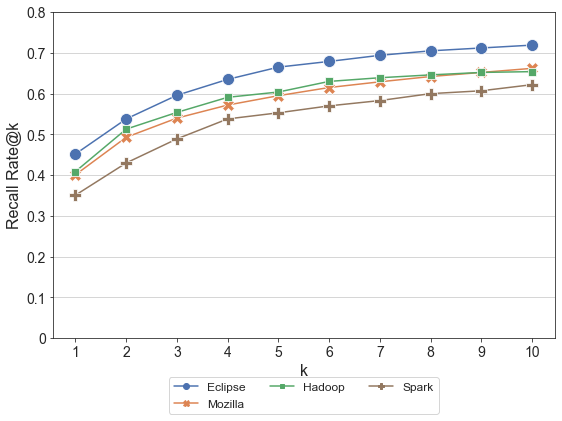

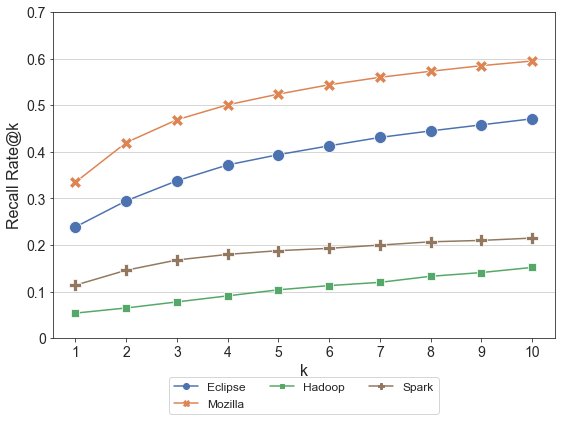

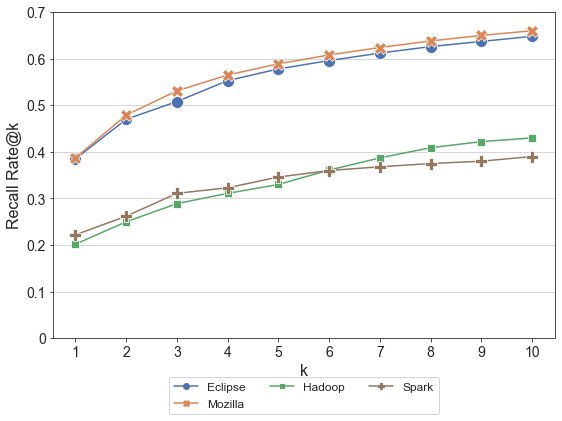

In [221]:
# Comparison - Bugzilla vs Jira (3 charts)

raw_num = {
    'REP': {
        'Eclipse':[0.452,0.538,0.596,0.635,0.665,0.679,0.694,0.705,0.712,0.719],
        'Mozilla':[0.401,0.493,0.540,0.572,0.595,0.615,0.629,0.642,0.652,0.662],
        'Hadoop':[0.409,0.513,0.554,0.591,0.604,0.630,0.639,0.646,0.652,0.654],
        'Spark':[0.351,0.430,0.489,0.538,0.553,0.570,0.583,0.600,0.607,0.622],
    },
    'Siamese-Pair': {
        'Eclipse':[0.239,0.295,0.338,0.372,0.394,0.413,0.431,0.445,0.458,0.471],
        'Mozilla':[0.335,0.420,0.469,0.501,0.524,0.544,0.560,0.573,0.585,0.595],
        'Hadoop':[0.054,0.065,0.078,0.091,0.104,0.113,0.120,0.133,0.141,0.152],
        'Spark':[0.114,0.146,0.168,0.180,0.188,0.193,0.200,0.207,0.210,0.215],
    },
    'SABD': {
        'Eclipse':[0.385,0.470,0.508,0.553,0.578,0.596,0.612,0.626,0.637,0.648],
        'Mozilla':[0.387,0.479,0.531,0.565,0.589,0.608,0.624,0.638,0.650,0.660],
        'Hadoop':[0.202,0.250,0.289,0.311,0.330,0.361,0.387,0.409,0.422,0.430],
        'Spark':[0.222,0.262,0.311,0.323,0.346,0.360,0.368,0.375,0.380,0.390],
    }
}


for project_name in raw_num:
    data = raw_num[project_name]
    y_min = 1
    y_max = 0

    for key in data:
        y_min = min(y_min, min(data[key]))
        y_max = max(y_max, max(data[key]))

    y_min = max(0, y_min-0.05*y_min)
    y_max = min(1, y_max+0.05*y_max)

    recall_rate_res = {}
    for key in data:
        recall_rate_res[key] = np.asarray([data[key]])

    sn.set_style("ticks")
    flatui = ["#4C72B0", "#DD8452", "#55A868", "#937860", "#8C8C8C", "#C44E52"]
    sn.set_palette(sn.color_palette(flatui))

    plt.figure(figsize=(9, 6))

    order = data.keys()

    k = list(range(1,11))
    ax = sn.lineplot(x="k",y='Recall Rate@k',ci='sd', hue='method', style='method', markers=True, markersize=12, dashes=False, data=convert2dataframe(recall_rate_res,order))
    # ax.set(title=f"{project_name} (Bugzilla vs Jira)")
    # ax.title.set_fontsize(14)

    import matplotlib.ticker as ticker
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())

    ax.set(ylim=(y_min, y_max))
    leg = ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=4, fontsize=12)
    leg_lines = leg.get_lines()

        # leg = ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3, fontsize=12)
    leg_lines = ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3, fontsize=12).get_lines()

    y_min = 0
    ax.set(ylim=(y_min, y_max))
    #  set the ticks first
    
    ax.set_xlabel("k",fontsize=16)
    ax.set_ylabel("Recall Rate@k",fontsize=16)
    tick = y_min
    tick_label=[int(0)]
    while tick <= y_max:
        tick_label.append(tick + 0.1)
        tick += 0.1

    ax.tick_params(labelsize=14)
    ax.set_yticks(tick_label)

    tick_label = [str(round(x,1)) for x in tick_label]
    tick_label[0] = int(0)
    ax.set_yticklabels(tick_label)

    ax.grid()
    ax.grid(axis='x')

    fig = ax.get_figure()
    fig.savefig(f"30Aug_plots/Comparison-{project_name}-Bugzilla-vs-Jira.pdf", format='pdf', bbox_inches='tight', pad_inches=0)

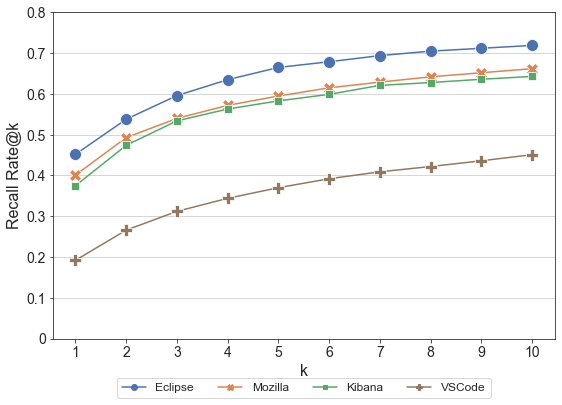

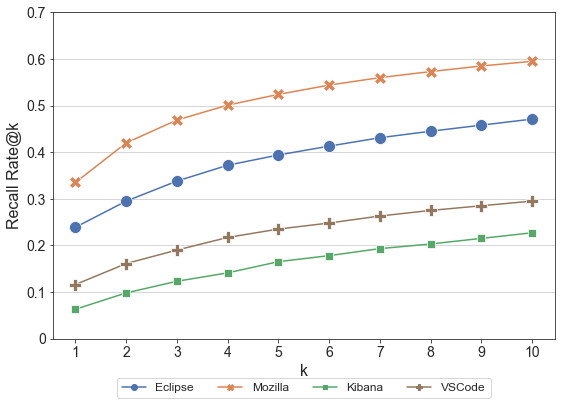

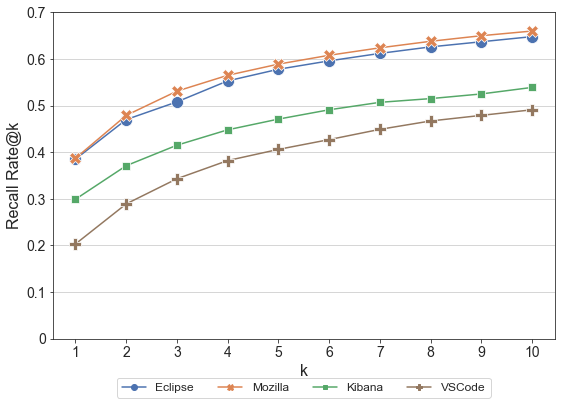

In [222]:
# Comparison - Bugzilla vs Github (3 charts)

raw_num = {
    'REP': {
        'Eclipse':[0.452,0.538,0.596,0.635,0.665,0.679,0.694,0.705,0.712,0.719],
        'Mozilla':[0.401,0.493,0.540,0.572,0.595,0.615,0.629,0.642,0.652,0.662],
        'Kibana':[0.375,0.474,0.534,0.563,0.583,0.599,0.621,0.628,0.636,0.643],
        'VSCode':[0.192,0.266,0.312,0.344,0.370,0.392,0.409,0.422,0.436,0.451],
    },
    'Pairs': {
        'Eclipse':[0.239,0.295,0.338,0.372,0.394,0.413,0.431,0.445,0.458,0.471],
        'Mozilla':[0.335,0.420,0.469,0.501,0.524,0.544,0.560,0.573,0.585,0.595],
        'Kibana':[0.063,0.098,0.123,0.141,0.165,0.178,0.193,0.203,0.215,0.227],
        'VSCode':[0.116,0.161,0.190,0.217,0.235,0.248,0.263,0.275,0.285,0.295],
    },
    'SABD': {
        'Eclipse':[0.385,0.470,0.508,0.553,0.578,0.596,0.612,0.626,0.637,0.648],
        'Mozilla':[0.387,0.479,0.531,0.565,0.589,0.608,0.624,0.638,0.650,0.660],
        'Kibana':[0.299,0.371,0.415,0.448,0.471,0.491,0.507,0.515,0.525,0.539],
        'VSCode':[0.203,0.289,0.343,0.382,0.406,0.427,0.449,0.467,0.479,0.491],
    }
}


for project_name in raw_num:
    data = raw_num[project_name]
    y_min = 1
    y_max = 0

    for key in data:
        y_min = min(y_min, min(data[key]))
        y_max = max(y_max, max(data[key]))

    y_min = max(0, y_min-0.05*y_min)
    y_max = min(1, y_max+0.05*y_max)

    recall_rate_res = {}
    for key in data:
        recall_rate_res[key] = np.asarray([data[key]])

    sn.set_style("ticks")
    flatui = ["#4C72B0", "#DD8452", "#55A868", "#937860", "#8C8C8C", "#C44E52"]
    sn.set_palette(sn.color_palette(flatui))

    plt.figure(figsize=(9, 6))

    order = data.keys()

    k = list(range(1,11))
    ax = sn.lineplot(x="k",y='Recall Rate@k',ci='sd', hue='method', style='method', markers=True, markersize=12, dashes=False, data=convert2dataframe(recall_rate_res,order))
    # ax.set(title=f"{project_name} (Bugzilla vs Github)")
    # ax.title.set_fontsize(14)

    import matplotlib.ticker as ticker
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())

    ax.set(ylim=(y_min, y_max))
    leg = ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=4, fontsize=12)
    leg_lines = leg.get_lines()

    y_min = 0
    ax.set(ylim=(y_min, y_max))
    #  set the ticks first
    
    ax.set_xlabel("k",fontsize=16)
    ax.set_ylabel("Recall Rate@k",fontsize=16)
    tick = y_min
    tick_label=[int(0)]
    while tick <= y_max:
        tick_label.append(tick + 0.1)
        tick += 0.1

    ax.tick_params(labelsize=14)
    ax.set_yticks(tick_label)

    tick_label = [str(round(x,1)) for x in tick_label]
    tick_label[0] = int(0)
    ax.set_yticklabels(tick_label)

    ax.grid()
    ax.grid(axis='x')

    fig = ax.get_figure()
    fig.savefig(f"30Aug_plots/Comparison-{project_name}-Bugzilla-vs-Github.pdf", format='pdf', bbox_inches='tight', pad_inches=0)

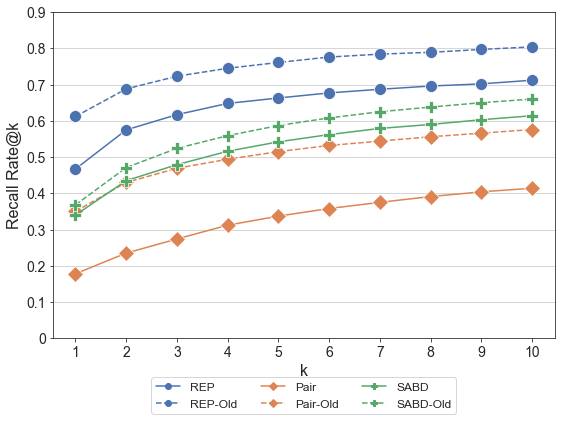

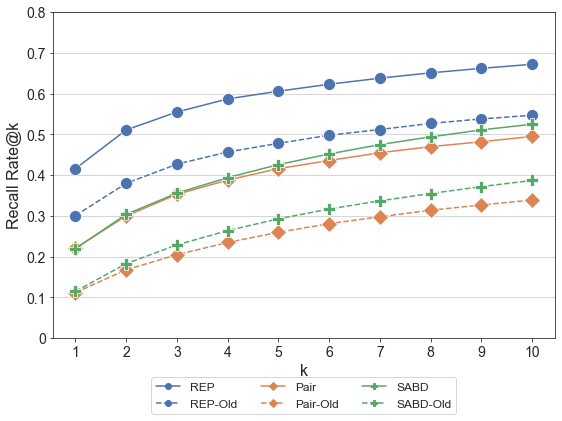

In [223]:
# Discussion-Sampled-Age (2 charts)

raw_num = {
    'Eclipse': 
        {'REP': [0.467,0.575,0.617,0.648,0.663,0.677,0.687,0.696,0.702,0.712],
        'Pair': [0.178,0.235,0.274,0.312,0.337,0.358,0.375,0.391,0.404,0.414],
        'SABD': [0.340,0.435,0.479,0.516,0.542,0.562,0.579,0.590,0.603,0.614],
        'REP-Old': [0.612,0.688,0.723,0.745,0.761,0.776,0.784,0.789,0.797,0.804],
        'Pair-Old': [0.350,0.430,0.469,0.494,0.515,0.532,0.544,0.556,0.566,0.576],
        'SABD-Old': [0.368,0.471,0.524,0.559,0.587,0.608,0.625,0.638,0.650,0.660],
    } ,
    "Mozilla": 
        {'REP': [0.416,0.511,0.555,0.587,0.606,0.623,0.638,0.651,0.662,0.672],
        'Pair': [0.221,0.300,0.353,0.388,0.416,0.436,0.455,0.470,0.482,0.495],
        'SABD': [0.220,0.304,0.356,0.394,0.426,0.452,0.475,0.494,0.511,0.525],
        'REP-Old': [0.301,0.380,0.427,0.457,0.478,0.498,0.512,0.527,0.538,0.547],
        'Pair-Old': [0.112,0.168,0.205,0.235,0.260,0.281,0.298,0.314,0.327,0.339],
        'SABD-Old': [0.115,0.183,0.229,0.264,0.293,0.317,0.337,0.355,0.372,0.387],
    }
}

for project_name in raw_num:
    data = raw_num[project_name]
    y_min = 1
    y_max = 0

    for key in data:
        y_min = min(y_min, min(data[key]))
        y_max = max(y_max, max(data[key]))

    y_min = max(0, y_min-0.05*y_min)
    y_max = min(1, y_max+0.05*y_max)
    tech_order = {0: "REP", 1: "REP-Old", 2: "Pair", 3: "Pair-Old", 4: "SABD", 5: "SABD-Old"}

    recall_rate_res = {
    'REP': np.asarray([
        data['REP']
        ]),
    "Pair":  np.asarray([
        data['Pair']
        ]),
    "SABD":  np.asarray([
        data['SABD']
        ]),
    "REP-Old":  np.asarray([
        data['REP-Old']
        ]),
    "Pair-Old":  np.asarray([
        data['Pair-Old']
        ]),
    "SABD-Old":  np.asarray([
        data['SABD-Old']
        ])
    }

    sn.set_style("ticks")
    flatui = ["#4C72B0", "#4C72B0", "#DD8452", "#DD8452", "#55A868", "#55A868"]
    # "#937860", "#8C8C8C", "#C44E52"]
    sn.set_palette(sn.color_palette(flatui))

    plt.figure(figsize=(9, 6))

    # order = ["REP", "Siamese-Pair", "SABD", "DC-CNN", "HINDBR", "FTS"]
    order = tech_order.values()

    # order.reverse()

    k = list(range(1,11))
    ax = sn.lineplot(x="k",y='Recall Rate@k',ci='sd', hue='method', style='method', markers=True, markersize=12, dashes=False, data=convert2dataframe(recall_rate_res,order))
    # ax.set(title=f"Sampled - {project_name} recent vs {project_name} old")
    # ax.title.set_fontsize(14)

    import matplotlib.ticker as ticker
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())

    ax.set(ylim=(y_min, y_max))
    leg = ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3, fontsize=12)
    leg_lines = leg.get_lines()

    for i in range(6):
        if i%2 == 1:
            ax.lines[i].set_linestyle("--")
            leg_lines[i].set_linestyle("--")

    for i in range(6):
        if i < 2:
            ax.lines[i].set_marker('o')
            leg_lines[i].set_marker("o")
            continue
        if i < 4:
            ax.lines[i].set_marker('D')
            leg_lines[i].set_marker("D")
        else:
            ax.lines[i].set_marker('P')
            leg_lines[i].set_marker("P")

    y_min = 0
    ax.set(ylim=(y_min, y_max))
    #  set the ticks first
    
    ax.set_xlabel("k",fontsize=16)
    ax.set_ylabel("Recall Rate@k",fontsize=16)
    tick = y_min
    tick_label=[int(0)]
    while tick <= y_max:
        tick_label.append(tick + 0.1)
        tick += 0.1

    ax.tick_params(labelsize=14)
    ax.set_yticks(tick_label)

    tick_label = [str(round(x,1)) for x in tick_label]
    tick_label[0] = int(0)
    ax.set_yticklabels(tick_label)

    ax.grid()
    ax.grid(axis='x')

    fig = ax.get_figure()
    fig.savefig(f"30Aug_plots/Discussion-Sampled-Age-{project_name}.pdf", format='pdf', bbox_inches='tight', pad_inches=0)

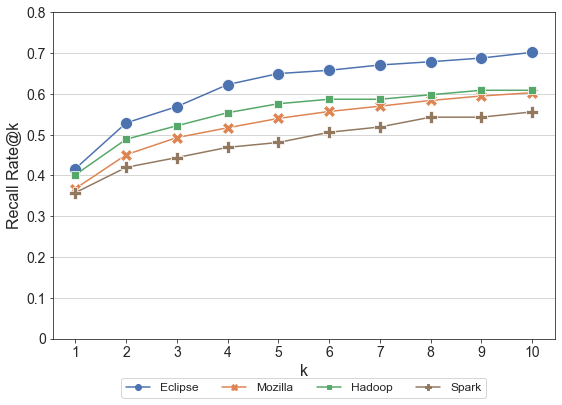

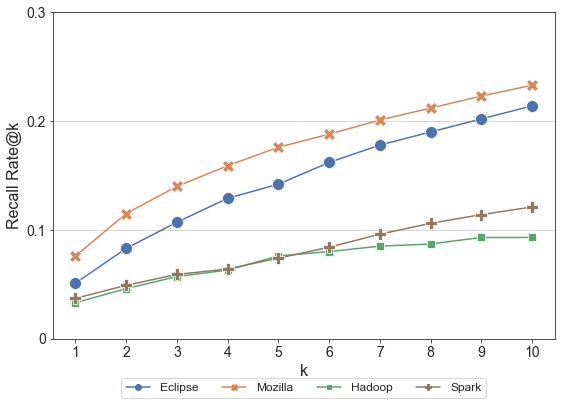

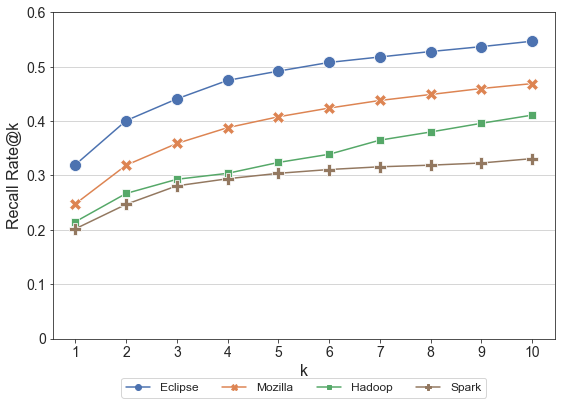

In [224]:
# Discussion-Sample-ITS - Bugzilla vs Jira (3 charts)

raw_num = {
    'REP': {
        'Eclipse':[0.417,0.529,0.569,0.623,0.650,0.658,0.671,0.679,0.688,0.702],
        'Mozilla':[0.368,0.451,0.493,0.517,0.540,0.557,0.570,0.584,0.595,0.603],
        'Hadoop':[0.402,0.489,0.522,0.554,0.576,0.587,0.587,0.598,0.609,0.609],
        'Spark':[0.358,0.420,0.444,0.469,0.481,0.506,0.519,0.543,0.543,0.556],
    },
    'Pairs': {
        'Eclipse':[0.051,0.083,0.107,0.129,0.142,0.162,0.178,0.190,0.202,0.214],
        'Mozilla':[0.076,0.115,0.140,0.159,0.176,0.188,0.201,0.212,0.223,0.233],
        'Hadoop':[0.033,0.046,0.057,0.063,0.076,0.080,0.085,0.087,0.093,0.093],
        'Spark':[0.037,0.049,0.059,0.064,0.074,0.084,0.096,0.106,0.114,0.121],
    },
    'SABD': {
        'Eclipse':[0.320,0.401,0.441,0.475,0.492,0.508,0.518,0.528,0.537,0.547],
        'Mozilla':[0.248,0.319,0.359,0.388,0.408,0.424,0.438,0.449,0.460,0.469],
        'Hadoop':[0.215,0.267,0.293,0.304,0.324,0.339,0.365,0.380,0.396,0.411],
        'Spark':[0.202,0.247,0.281,0.294,0.304,0.311,0.316,0.319,0.323,0.331],
    }
}


for project_name in raw_num:
    data = raw_num[project_name]
    y_min = 1
    y_max = 0

    for key in data:
        y_min = min(y_min, min(data[key]))
        y_max = max(y_max, max(data[key]))

    y_min = max(0, y_min-0.05*y_min)
    y_max = min(1, y_max+0.05*y_max)

    recall_rate_res = {}
    for key in data:
        recall_rate_res[key] = np.asarray([data[key]])

    sn.set_style("ticks")
    flatui = ["#4C72B0", "#DD8452", "#55A868", "#937860", "#8C8C8C", "#C44E52"]
    sn.set_palette(sn.color_palette(flatui))

    plt.figure(figsize=(9, 6))

    order = data.keys()

    k = list(range(1,11))
    ax = sn.lineplot(x="k",y='Recall Rate@k',ci='sd', hue='method', style='method', markers=True, markersize=12, dashes=False, data=convert2dataframe(recall_rate_res,order))
    # ax.set(title=f"Sampled - {project_name} (Bugzilla vs Jira)")
    # ax.title.set_fontsize(14)

    import matplotlib.ticker as ticker
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())

    ax.set(ylim=(y_min, y_max))
    leg = ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=4, fontsize=12)
    leg_lines = leg.get_lines()

    y_min = 0
    ax.set(ylim=(y_min, y_max))
    #  set the ticks first
    
    ax.set_xlabel("k",fontsize=16)
    ax.set_ylabel("Recall Rate@k",fontsize=16)
    tick = y_min
    tick_label=[int(0)]
    while tick <= y_max:
        tick_label.append(tick + 0.1)
        tick += 0.1

    ax.tick_params(labelsize=14)
    ax.set_yticks(tick_label)

    tick_label = [str(round(x,1)) for x in tick_label]
    tick_label[0] = int(0)
    ax.set_yticklabels(tick_label)

    ax.grid()
    ax.grid(axis='x')

    fig = ax.get_figure()
    fig.savefig(f"30Aug_plots/Discussion-Sample-ITS-{project_name}-Bugzilla-vs-Jira.pdf", format='pdf', bbox_inches='tight', pad_inches=0)

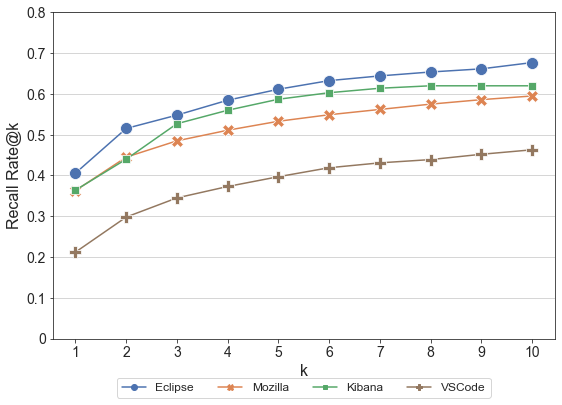

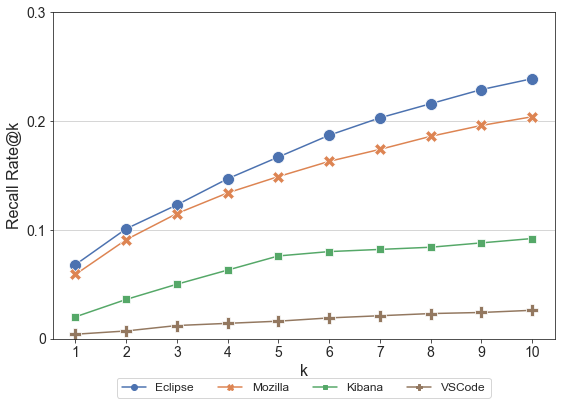

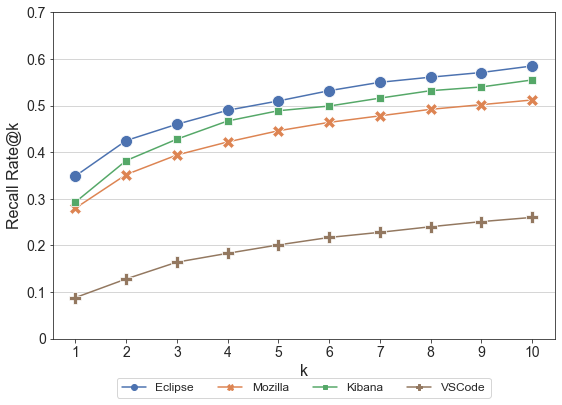

In [228]:
# Discussion-Sample-ITS - Bugzilla vs Github (3 charts)

raw_num = {
    'REP': {
        'Eclipse':[0.405769,0.515385,0.548077,0.584615,0.611538,0.632692,0.644231,0.653846,0.661538,0.676923],
        'Mozilla':[0.363,0.445,0.485,0.511,0.533,0.549,0.562,0.575,0.586,0.595],
        'Kibana':[0.364,0.440,0.527,0.560,0.587,0.603,0.614,0.620,0.620,0.620],
        'VSCode':[0.212,0.298,0.345,0.373,0.397,0.419,0.431,0.439,0.452,0.463],
    },
    'Pairs': {
        'Eclipse':[0.068,0.101,0.123,0.147,0.167,0.187,0.203,0.216,0.229,0.239],
        'Mozilla':[0.059,0.091,0.115,0.134,0.149,0.163,0.174,0.186,0.196,0.204],
        'Kibana':[0.020,0.036,0.050,0.063,0.076,0.080,0.082,0.084,0.088,0.092],
        'VSCode':[0.004,0.007,0.012,0.014,0.016,0.019,0.021,0.023,0.024,0.026],
    },
    'SABD': {
        'Eclipse':[0.349,0.425,0.460,0.490,0.510,0.532,0.550,0.561,0.571,0.585],
        'Mozilla':[0.280,0.352,0.394,0.422,0.446,0.464,0.478,0.492,0.502,0.512],
        'Kibana':[0.293,0.382,0.428,0.467,0.489,0.499,0.516,0.532,0.540,0.555],
        'VSCode':[0.088,0.128,0.164,0.183,0.201,0.217,0.228,0.240,0.251,0.260],
    }
}


for project_name in raw_num:
    data = raw_num[project_name]
    y_min = 1
    y_max = 0

    for key in data:
        y_min = min(y_min, min(data[key]))
        y_max = max(y_max, max(data[key]))

    y_min = max(0, y_min-0.05*y_min)
    y_max = min(1, y_max+0.05*y_max)

    recall_rate_res = {}
    for key in data:
        recall_rate_res[key] = np.asarray([data[key]])

    sn.set_style("ticks")
    flatui = ["#4C72B0", "#DD8452", "#55A868", "#937860", "#8C8C8C", "#C44E52"]
    sn.set_palette(sn.color_palette(flatui))

    plt.figure(figsize=(9, 6))

    order = data.keys()

    k = list(range(1,11))
    ax = sn.lineplot(x="k",y='Recall Rate@k',ci='sd', hue='method', style='method', markers=True, markersize=12, dashes=False, data=convert2dataframe(recall_rate_res,order))
    # ax.set(title=f"Sampled - {project_name} (Bugzilla vs Github)")
    # ax.title.set_fontsize(14)

    import matplotlib.ticker as ticker
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())

    ax.set(ylim=(y_min, y_max))
    leg = ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=4, fontsize=12)
    leg_lines = leg.get_lines()

    y_min = 0
    ax.set(ylim=(y_min, y_max))
    #  set the ticks first
    
    ax.set_xlabel("k",fontsize=16)
    ax.set_ylabel("Recall Rate@k",fontsize=16)
    tick = y_min
    tick_label=[int(0)]
    while tick <= y_max:
        tick_label.append(tick + 0.1)
        tick += 0.1

    ax.tick_params(labelsize=14)
    ax.set_yticks(tick_label)

    tick_label = [str(round(x,1)) for x in tick_label]
    tick_label[0] = int(0)
    ax.set_yticklabels(tick_label)

    ax.grid()
    ax.grid(axis='x')

    fig = ax.get_figure()
    fig.savefig(f"30Aug_plots/Discussion-Sample-ITS-{project_name}-Bugzilla-vs-Github.pdf", format='pdf', bbox_inches='tight', pad_inches=0)

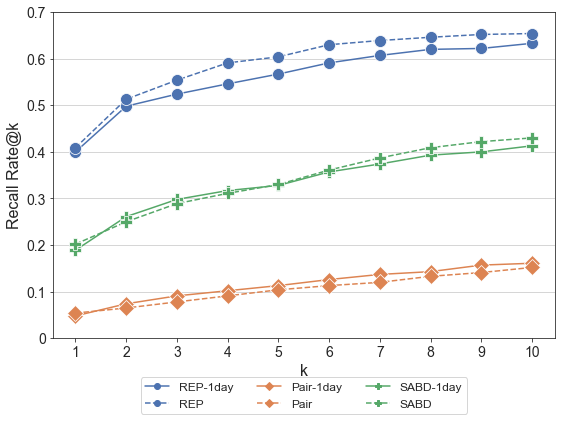

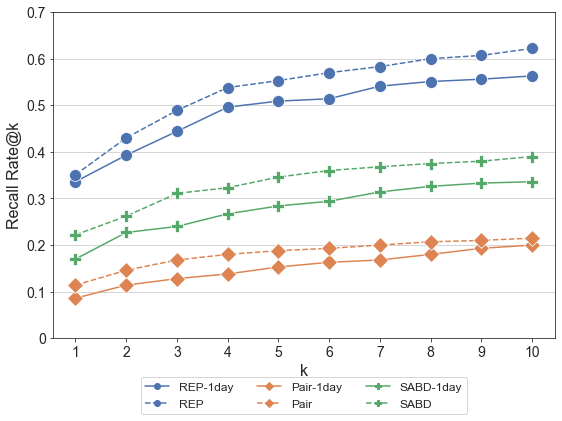

In [229]:
# Discussion-State-Jira (2 charts)

raw_num = {
    'Hadoop': 
        {'REP': [0.409,0.513,0.554,0.591,0.604,0.630,0.639,0.646,0.652,0.654],
        'Pair': [0.054,0.065,0.078,0.091,0.104,0.113,0.120,0.133,0.141,0.152],
        'SABD': [0.202,0.250,0.289,0.311,0.330,0.361,0.387,0.409,0.422,0.430],
        'REP-1day': [0.400,0.498,0.524,0.546,0.567,0.591,0.607,0.620,0.622,0.633],
        'Pair-1day': [0.048,0.074,0.091,0.102,0.113,0.126,0.137,0.143,0.157,0.161],
        'SABD-1day': [0.189,0.261,0.298,0.317,0.328,0.357,0.374,0.393,0.400,0.413],
    } ,
    "Spark": 
        {'REP': [0.351,0.430,0.489,0.538,0.553,0.570,0.583,0.600,0.607,0.622],
        'Pair': [0.114,0.146,0.168,0.180,0.188,0.193,0.200,0.207,0.210,0.215],
        'SABD': [0.222,0.262,0.311,0.323,0.346,0.360,0.368,0.375,0.380,0.390],
        'REP-1day': [0.336,0.393,0.444,0.496,0.509,0.514,0.541,0.551,0.556,0.563],
        'Pair-1day': [0.086,0.114,0.128,0.138,0.153,0.163,0.168,0.180,0.193,0.200],
        'SABD-1day': [0.170,0.227,0.240,0.267,0.284,0.294,0.314,0.326,0.333,0.336],
    }
}

for project_name in raw_num:
    data = raw_num[project_name]
    y_min = 1
    y_max = 0

    for key in data:
        y_min = min(y_min, min(data[key]))
        y_max = max(y_max, max(data[key]))

    y_min = max(0, y_min-0.05*y_min)
    y_max = min(1, y_max+0.05*y_max)
    tech_order = {0: "REP-1day", 1: "REP", 2: "Pair-1day", 3: "Pair", 4: "SABD-1day", 5: "SABD"}

    recall_rate_res = {}
    for key in data:
        recall_rate_res[key] = np.asarray([data[key]])

    sn.set_style("ticks")
    flatui = ["#4C72B0", "#4C72B0", "#DD8452", "#DD8452", "#55A868", "#55A868"]
    # "#937860", "#8C8C8C", "#C44E52"]
    sn.set_palette(sn.color_palette(flatui))

    plt.figure(figsize=(9, 6))

    # order = ["REP", "Siamese-Pair", "SABD", "DC-CNN", "HINDBR", "FTS"]
    order = tech_order.values()

    # order.reverse()

    k = list(range(1,11))
    ax = sn.lineplot(x="k",y='Recall Rate@k',ci='sd', hue='method', style='method', markers=True, markersize=12, dashes=False, data=convert2dataframe(recall_rate_res,order))
    # ax.set(title=f"{project_name} State")
    # ax.title.set_fontsize(14)

    import matplotlib.ticker as ticker
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())

    ax.set(ylim=(y_min, y_max))
    leg = ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3, fontsize=12)
    leg_lines = leg.get_lines()

    for i in range(6):
        if i%2 == 1:
            ax.lines[i].set_linestyle("--")
            leg_lines[i].set_linestyle("--")

    for i in range(6):
        if i < 2:
            ax.lines[i].set_marker('o')
            leg_lines[i].set_marker("o")
            continue
        if i < 4:
            ax.lines[i].set_marker('D')
            leg_lines[i].set_marker("D")
        else:
            ax.lines[i].set_marker('P')
            leg_lines[i].set_marker("P")

    y_min = 0
    ax.set(ylim=(y_min, y_max))
    #  set the ticks first
    
    ax.set_xlabel("k",fontsize=16)
    ax.set_ylabel("Recall Rate@k",fontsize=16)
    tick = y_min
    tick_label=[int(0)]
    while tick <= y_max:
        tick_label.append(tick + 0.1)
        tick += 0.1

    ax.tick_params(labelsize=14)
    ax.set_yticks(tick_label)

    tick_label = [str(round(x,1)) for x in tick_label]
    tick_label[0] = int(0)
    ax.set_yticklabels(tick_label)

    ax.grid()
    ax.grid(axis='x')

    fig = ax.get_figure()
    fig.savefig(f"30Aug_plots/Discussion-State-Jira-{project_name}.pdf", format='pdf', bbox_inches='tight', pad_inches=0)

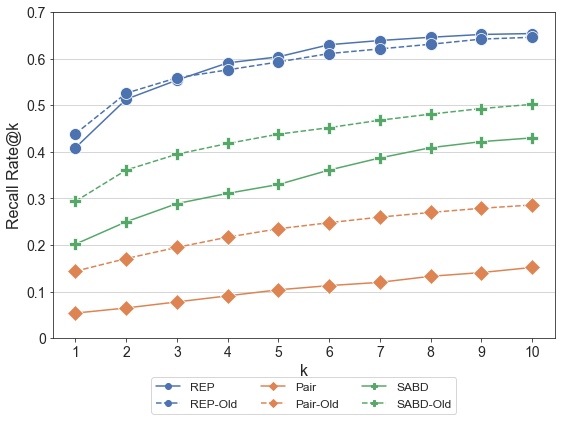

In [230]:
# Discussion-Age-Jira (1 charts)

raw_num = {
    'Hadoop': 
        {'REP': [0.409,0.513,0.554,0.591,0.604,0.630,0.639,0.646,0.652,0.654],
        'Pair': [0.054,0.065,0.078,0.091,0.104,0.113,0.120,0.133,0.141,0.152],
        'SABD': [0.202,0.250,0.289,0.311,0.330,0.361,0.387,0.409,0.422,0.430],
        'REP-Old': [0.439,0.526,0.559,0.576,0.593,0.611,0.621,0.631,0.642,0.646],
        'Pair-Old': [0.144,0.171,0.195,0.217,0.235,0.248,0.260,0.270,0.279,0.286],
        'SABD-Old': [0.294,0.361,0.395,0.418,0.438,0.452,0.468,0.481,0.493,0.502],
    } 
}

for project_name in raw_num:
    data = raw_num[project_name]
    y_min = 1
    y_max = 0

    for key in data:
        y_min = min(y_min, min(data[key]))
        y_max = max(y_max, max(data[key]))

    y_min = max(0, y_min-0.05*y_min)
    y_max = min(1, y_max+0.05*y_max)
    tech_order = {0: "REP", 1: "REP-Old", 2: "Pair", 3: "Pair-Old", 4: "SABD", 5: "SABD-Old"}

    recall_rate_res = {}
    for key in data:
        recall_rate_res[key] = np.asarray([data[key]])

    sn.set_style("ticks")
    flatui = ["#4C72B0", "#4C72B0", "#DD8452", "#DD8452", "#55A868", "#55A868"]
    # "#937860", "#8C8C8C", "#C44E52"]
    sn.set_palette(sn.color_palette(flatui))

    plt.figure(figsize=(9, 6))

    order = tech_order.values()

    k = list(range(1,11))
    ax = sn.lineplot(x="k",y='Recall Rate@k',ci='sd', hue='method', style='method', markers=True, markersize=12, dashes=False, data=convert2dataframe(recall_rate_res,order))
    # ax.set(title=f"{project_name} Age (Jira)")
    # ax.title.set(fontsize=14)

    import matplotlib.ticker as ticker
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())

    ax.set(ylim=(y_min, y_max))
    leg = ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3, fontsize=12)
    leg_lines = leg.get_lines()

    for i in range(6):
        if i%2 == 1:
            ax.lines[i].set_linestyle("--")
            leg_lines[i].set_linestyle("--")

    for i in range(6):
        if i < 2:
            ax.lines[i].set_marker('o')
            leg_lines[i].set_marker("o")
            continue
        if i < 4:
            ax.lines[i].set_marker('D')
            leg_lines[i].set_marker("D")
        else:
            ax.lines[i].set_marker('P')
            leg_lines[i].set_marker("P")

    y_min = 0
    ax.set(ylim=(y_min, y_max))
    #  set the ticks first
    
    ax.set_xlabel("k",fontsize=16)
    ax.set_ylabel("Recall Rate@k",fontsize=16)
    tick = y_min
    tick_label=[int(0)]
    while tick <= y_max:
        tick_label.append(tick + 0.1)
        tick += 0.1

    ax.tick_params(labelsize=14)
    ax.set_yticks(tick_label)

    tick_label = [str(round(x,1)) for x in tick_label]
    tick_label[0] = int(0)
    ax.set_yticklabels(tick_label)

    ax.grid()
    ax.grid(axis='x')

    fig = ax.get_figure()
    fig.savefig(f"30Aug_plots/Discussion-Age-Jira-{project_name}.pdf", format='pdf', bbox_inches='tight', pad_inches=0)